# OpenVals — Trust layer of AI
## Episode 01: What Is AI, Really?

### The central question

> **When an AI gives us an answer, how do we know whether we should trust it?**

Today we will learn:

1. What AI and Machine Learning mean
2. Traditional programming vs machine learning
3. What **data**, **input**, **output**, and **model** mean
4. The idea behind \(y=f(x)\)
5. How a tiny machine-learning model learns from examples
6. Why a prediction is not automatically the truth
7. Why **validation** exists

---

**“AI engineering creates the model. AI validation investigates the model.”**

Keep this notebook open while presenting. Run one cell at a time.


## 0. Mac Compatibility Check

This notebook intentionally avoids heavyweight AI frameworks.

It uses:

- Python standard library
- NumPy
- Matplotlib

It does **not** require:

- NVIDIA/CUDA
- TensorFlow
- PyTorch
- Apple Metal acceleration
- cloud APIs
- an LLM API key

So it is suitable for both **Apple Silicon Macs (M-series)** and **Intel Macs**.


In [1]:
import platform
import sys

print("Python version :", sys.version.split()[0])
print("Operating system:", platform.system(), platform.release())
print("Machine         :", platform.machine())
print("Processor       :", platform.processor() or "Not reported by macOS")

if platform.system() == "Darwin":
    print("\n✅ macOS detected.")
    if platform.machine() == "arm64":
        print("✅ Apple Silicon detected (M-series architecture).")
    elif platform.machine() == "x86_64":
        print("✅ Intel Mac detected.")
else:
    print("\nℹ️ This notebook is Mac-friendly, but it can also run on this OS.")


Python version : 3.12.4
Operating system: Darwin 25.5.0
Machine         : arm64
Processor       : arm

✅ macOS detected.
✅ Apple Silicon detected (M-series architecture).


### If NumPy or Matplotlib is missing

Run the next cell **only if an import fails**.

On a normal Jupyter installation, you may already have both packages.


In [ ]:
# Uncomment ONLY if needed:
# %pip install -q numpy matplotlib


In [2]:
import numpy as np
import matplotlib.pyplot as plt

print("✅ NumPy:", np.__version__)
print("✅ Matplotlib is ready.")


✅ NumPy: 2.4.6
✅ Matplotlib is ready.


# 1. First remove the magic from AI

Write this on your physical board:

```text
INPUT
  ↓
 AI
  ↓
OUTPUT
```

Then ask:

> **“What happened inside the AI box?”**

AI is not magic.

At a very simple level, a system receives an **input**, performs some process, and produces an **output**.

For machine learning, we can express the idea as:

\[
y=f(x)
\]

Where:

- \(x\) = input
- \(f\) = model or learned relationship
- \(y\) = output

Later we will make this more precise.


# 2. Traditional Programming vs Machine Learning

### Traditional programming

A programmer writes the rules.

```text
DATA + RULES
     ↓
 PROGRAM
     ↓
 ANSWER
```

### Machine learning

Instead of manually specifying every rule, we provide examples and allow an algorithm to discover useful patterns.

```text
DATA + EXAMPLES
      ↓
   LEARNING
      ↓
    MODEL
      ↓
  PREDICTION
```


## Experiment 1 — Traditional Programming

Suppose we want a computer to decide whether someone is legally an adult using a deliberately simplified rule.

We explicitly write the rule ourselves.


In [ ]:
def traditional_program(age):
    if age >= 18:
        return "Adult"
    return "Minor"

for age in [10, 17, 18, 25, 60]:
    print(f"Age {age:>2} → {traditional_program(age)}")

Age 10 → Minor
Age 17 → Minor
Age 18 → Adult
Age 25 → Adult
Age 60 → Adult


### Ask the audience

**Did the computer learn anything?**

No.

We wrote the rule:

```python
age >= 18
```

The computer merely followed our instruction.

That is the key distinction.


# 3. What does “learning from examples” mean?

Imagine teaching a child:

| Fruit | Approx. weight | Label |
|---|---:|---|
| Small fruit | 110 g | Apple |
| Small fruit | 125 g | Apple |
| Large fruit | 190 g | Orange |
| Large fruit | 210 g | Orange |

After enough examples, you show a fruit weighing **200 g**.

The child may infer that it is more likely to be an orange.

The child was not given a giant rulebook.

It recognized a **pattern**.

Machine learning follows the same broad idea, although the mathematical mechanism is much more precise.


In [4]:
fruit_weights = np.array([110, 125, 190, 210])
fruit_names = np.array(["Apple", "Apple", "Orange", "Orange"])

for weight, fruit in zip(fruit_weights, fruit_names):
    print(f"{weight} g → {fruit}")


110 g → Apple
125 g → Apple
190 g → Orange
210 g → Orange


## A deliberately simple “learned boundary”

For teaching purposes, we can let the examples suggest a boundary between the heaviest apple and lightest orange.

This is **not** how all machine-learning algorithms work.

It is simply our first intuition for learning a pattern from data.


In [5]:
apple_weights = fruit_weights[fruit_names == "Apple"]
orange_weights = fruit_weights[fruit_names == "Orange"]

boundary = (apple_weights.max() + orange_weights.min()) / 2

print("Heaviest observed apple :", apple_weights.max(), "g")
print("Lightest observed orange:", orange_weights.min(), "g")
print("Learned boundary        :", boundary, "g")

def learned_fruit_model(weight):
    return "Orange" if weight >= boundary else "Apple"

for new_weight in [120, 150, 180, 200]:
    print(f"{new_weight} g → predicted {learned_fruit_model(new_weight)}")


Heaviest observed apple : 125 g
Lightest observed orange: 190 g
Learned boundary        : 157.5 g
120 g → predicted Apple
150 g → predicted Apple
180 g → predicted Orange
200 g → predicted Orange


### Thought-leadership point

A model does not necessarily understand an **apple** the way a human does.

It learns relationships present in the information we give it.

That immediately creates an important question:

> **What happens when our data does not represent reality properly?**

That question takes us toward **validation**.


# 4. From intuition to mathematics

A very useful mental model is:

\[
\hat{y}=f(x)
\]

The little hat in \(\hat{y}\) means:

> **predicted value**

It is deliberately different from \(y\), the actual value.

That distinction is fundamental to model validation.

```text
ACTUAL VALUE       → y
MODEL PREDICTION   → ŷ
DIFFERENCE         → error
```


# 5. Experiment 2 — A machine learns a numerical relationship

Imagine we are predicting a house price only from its size.

We will intentionally use a tiny artificial dataset so everyone can see what is happening.

This is **not a real property valuation model**.


In [6]:
# House size in square feet
X = np.array([600, 800, 1000, 1200, 1500, 1800, 2200], dtype=float)

# Artificial house prices in lakh rupees
y = np.array([42, 52, 63, 73, 88, 103, 124], dtype=float)

for size, price in zip(X, y):
    print(f"{int(size):>4} sq.ft. → ₹{price:.0f} lakh")


 600 sq.ft. → ₹42 lakh
 800 sq.ft. → ₹52 lakh
1000 sq.ft. → ₹63 lakh
1200 sq.ft. → ₹73 lakh
1500 sq.ft. → ₹88 lakh
1800 sq.ft. → ₹103 lakh
2200 sq.ft. → ₹124 lakh


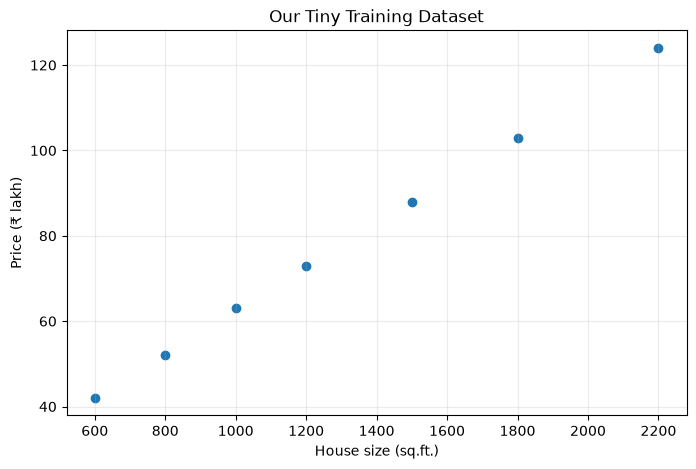

In [7]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y)
plt.xlabel("House size (sq.ft.)")
plt.ylabel("Price (₹ lakh)")
plt.title("Our Tiny Training Dataset")
plt.grid(alpha=0.25)
plt.show()


## What should the model learn?

We will use one of the simplest models in machine learning:

\[
\hat{y}=wx+b
\]

Where:

- \(x\) = house size
- \(w\) = learned slope
- \(b\) = learned intercept
- \(\hat{y}\) = predicted house price

The computer must find useful values for \(w\) and \(b\).

Those learned numbers are called **parameters**.


## Learn the parameters

NumPy can calculate the best-fitting straight line for this small example.

Don't worry about the mathematics yet.

For Episode 1, focus on what happened:

**Examples went in → parameters were learned → a model came out.**


In [8]:
w, b = np.polyfit(X, y, 1)

print(f"Learned w (slope)    = {w:.5f}")
print(f"Learned b (intercept)= {b:.2f}")

def house_price_model(size_sqft):
    return w * size_sqft + b


Learned w (slope)    = 0.05108
Learned b (intercept)= 11.45


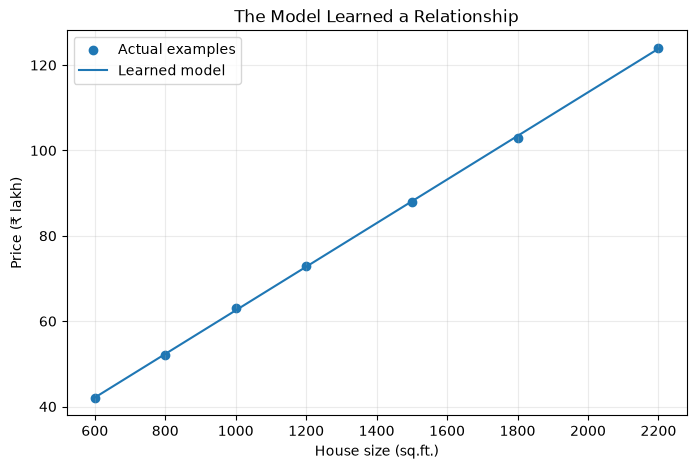

In [9]:
predictions = house_price_model(X)

plt.figure(figsize=(8, 5))
plt.scatter(X, y, label="Actual examples")
plt.plot(X, predictions, label="Learned model")
plt.xlabel("House size (sq.ft.)")
plt.ylabel("Price (₹ lakh)")
plt.title("The Model Learned a Relationship")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


# 6. Make a prediction

Now give the model something it did not directly receive as one of our examples.

Suppose the house is **2,000 sq.ft.**


In [10]:
new_house = 2000
predicted_price = house_price_model(new_house)

print(f"Input             : {new_house} sq.ft.")
print(f"Model prediction  : ₹{predicted_price:.2f} lakh")


Input             : 2000 sq.ft.
Model prediction  : ₹113.61 lakh


### Stop here during the broadcast.

Ask:

> **“The model has produced a number. Is that number automatically correct?”**

The answer is **NO**.

A prediction is not proof.

This is where many conversations about AI go wrong.


# 7. The birth of validation

Suppose the real market value later turns out to be ₹112 lakh.

Our model predicted something else.

Now we can measure an **error**.

\[
Error = Actual - Predicted
\]

and often:

\[
Absolute\ Error = |Actual-Predicted|
\]


In [11]:
actual_price = 112.0
error = actual_price - predicted_price
absolute_error = abs(error)

print(f"Predicted price : ₹{predicted_price:.2f} lakh")
print(f"Actual price    : ₹{actual_price:.2f} lakh")
print(f"Error           : ₹{error:.2f} lakh")
print(f"Absolute error  : ₹{absolute_error:.2f} lakh")


Predicted price : ₹113.61 lakh
Actual price    : ₹112.00 lakh
Error           : ₹-1.61 lakh
Absolute error  : ₹1.61 lakh


## But one correct answer still proves almost nothing

This is extremely important.

Imagine testing a student with **one question**.

If the student answers correctly, would you immediately award a PhD?

Of course not.

Likewise, one successful AI prediction does not establish that the model is trustworthy.

We need systematic evaluation.


# 8. Experiment 3 — Test the model on unseen examples

These examples were **not used to fit our model**.

That gives us our first taste of testing.


In [12]:
X_test = np.array([700, 1100, 1400, 1700, 2000, 2400], dtype=float)
y_test = np.array([47, 68, 84, 98, 112, 133], dtype=float)

y_pred = house_price_model(X_test)

print(" SIZE     ACTUAL    PREDICTED    ABS ERROR")
print("-" * 46)

for size, actual, pred in zip(X_test, y_test, y_pred):
    print(f"{int(size):>5}     {actual:>6.1f}      {pred:>7.2f}      {abs(actual-pred):>7.2f}")


 SIZE     ACTUAL    PREDICTED    ABS ERROR
----------------------------------------------
  700       47.0        47.21         0.21
 1100       68.0        67.64         0.36
 1400       84.0        82.97         1.03
 1700       98.0        98.29         0.29
 2000      112.0       113.61         1.61
 2400      133.0       134.05         1.05


# 9. Our first validation metric — MAE

A metric turns model behavior into something measurable.

One beginner-friendly metric for numerical prediction is:

## Mean Absolute Error (MAE)

Take every absolute error and calculate the average.

\[
MAE = rac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|
\]

Don't memorize the equation yet.

Read it in English:

> **“On average, how far away were my predictions from reality?”**


In [13]:
absolute_errors = np.abs(y_test - y_pred)
mae = absolute_errors.mean()

print(f"Mean Absolute Error = ₹{mae:.2f} lakh")


Mean Absolute Error = ₹0.76 lakh


In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, label="Actual")
plt.scatter(X_test, y_pred, label="Predicted")
plt.xlabel("House size (sq.ft.)")
plt.ylabel("Price (₹ lakh)")
plt.title("Actual vs Predicted — Our First Validation View")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


# 10. Now challenge the model

A model may behave well for familiar situations and badly for unusual situations.

Try changing the value below live.

Suggested values:

- 900
- 2,000
- 5,000
- 20,000
- -500

> **“Just because mathematics produced an answer, does that make the answer sensible?”**


In [14]:
experimental_size = 5000  # Change this during the live broadcast

experimental_prediction = house_price_model(experimental_size)

print(f"Input      : {experimental_size} sq.ft.")
print(f"Prediction : ₹{experimental_prediction:.2f} lakh")


Input      : 5000 sq.ft.
Prediction : ₹266.86 lakh


### Professor's insight

This is our first encounter with a much larger idea:

**A model can always produce an output while still being wrong, unsafe, unreasonable, or outside the conditions under which it was validated.**

That is why model validation asks more than:

> “Did the code run?”

It asks:

> **“Under what conditions should we trust the result?”**


# 11. A wrong dataset can produce a wrong model

Let's deliberately corrupt one training example.

This demonstrates why model quality depends on data quality.


In [15]:
X_bad = X.copy()
y_bad = y.copy()

# Deliberately corrupt one price:
y_bad[-1] = 300

w_bad, b_bad = np.polyfit(X_bad, y_bad, 1)

def bad_model(size_sqft):
    return w_bad * size_sqft + b_bad

good_prediction = house_price_model(2000)
bad_prediction = bad_model(2000)

print(f"Good-data model prediction at 2000 sq.ft.: ₹{good_prediction:.2f} lakh")
print(f"Bad-data model prediction at 2000 sq.ft. : ₹{bad_prediction:.2f} lakh")


Good-data model prediction at 2000 sq.ft.: ₹113.61 lakh
Bad-data model prediction at 2000 sq.ft. : ₹195.91 lakh


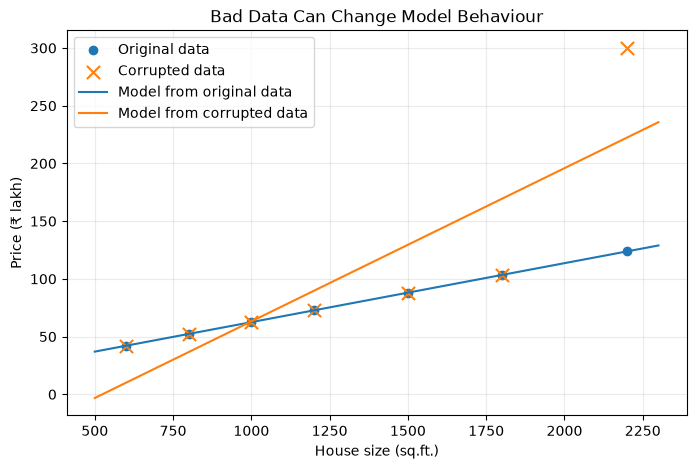

In [16]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, label="Original data")
plt.scatter(X_bad, y_bad, marker="x", s=90, label="Corrupted data")

x_line = np.linspace(500, 2300, 100)
plt.plot(x_line, house_price_model(x_line), label="Model from original data")
plt.plot(x_line, bad_model(x_line), label="Model from corrupted data")

plt.xlabel("House size (sq.ft.)")
plt.ylabel("Price (₹ lakh)")
plt.title("Bad Data Can Change Model Behaviour")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


# 12. The Five Questions of AI Validation

This will become our recurring framework throughout the series.

### 1. DOES IT WORK?
**Performance**

### 2. DOES IT WORK CONSISTENTLY?
**Reliability**

### 3. WHEN DOES IT FAIL?
**Robustness**

### 4. CAN IT CAUSE HARM?
**Safety**

### 5. CAN WE TRUST IT IN PRODUCTION?
**Assurance**

Today we only scratched the surface of Question 1.


# 13. Training, Testing, Validation — first mental model

For now, remember this simplified distinction:

```text
TRAIN
  ↓
Learn patterns from examples

TEST
  ↓
Measure behaviour on unseen examples

VALIDATE
  ↓
Determine whether the model is fit and trustworthy
for its intended use
```

Later episodes will make the terminology more rigorous because the words **validation** and **test** also have specific meanings in statistical machine-learning workflows.


# 14. OpenVals connection

Do **not** turn this into a sales pitch during the lecture.

Instead say:

> “Today we evaluated one tiny model with one dataset and one error metric. Real AI systems may require many datasets, many models, many metrics, safety checks, robustness tests, repeated evaluations, and continuous monitoring.”

Then draw:

```text
MANUAL EVALUATION
        ↓
AUTOMATED EVALUATION
        ↓
CONTINUOUS VALIDATION
        ↓
AI ASSURANCE
```

And close with:

> **“That larger validation problem is one of the areas we're working on through OpenVals.”**


# 15. Live Audience Experiments

Use these during Q&A.

### Experiment A
Change the test house sizes.

### Experiment B
Change one training price dramatically.

### Experiment C
Remove one training example.

### Experiment D
Add more training examples.

### Experiment E
Predict a ridiculous value such as `100000` sq.ft.

For every experiment ask only three questions:

1. **What changed?**
2. **Why did the model behave differently?**
3. **Would you trust this prediction in the real world?**

Those three questions begin teaching the audience to think like **AI validators rather than AI consumers**.


In [17]:
# Audience sandbox — safely edit these values during the broadcast.

audience_size = 3000
prediction = house_price_model(audience_size)

print(f"For a {audience_size:,} sq.ft. house,")
print(f"our tiny educational model predicts ₹{prediction:.2f} lakh.")
print("\nQuestion: Should we trust it? Why or why not?")


For a 3,000 sq.ft. house,
our tiny educational model predicts ₹164.70 lakh.

Question: Should we trust it? Why or why not?


# 16. Episode 01 Recap

If the audience remembers only six things, make it these:

1. **AI is not magic.**
2. Machine learning discovers patterns from examples.
3. A **model** is a learned mathematical relationship.
4. A model produces a **prediction**, not guaranteed truth.
5. Prediction and reality can differ — that difference can be measured.
6. **Validation is how we investigate whether an AI model deserves trust.**

---

## Closing line for the broadcast

> **“The future of AI will not be decided only by who can build the most powerful models. It will also be decided by who can prove that those models deserve our trust.”**

### Next Episode

**Episode 02 — What Is Machine Learning?**

We will go deeper into:

- learning from data
- features and labels
- supervised learning
- training
- parameters
- predictions
- the first idea of generalization
